# **Laboratorio Dirigido 03**
## **Tema: Control teleoperado**

Estudiante:

Código:

Importación de librerías y definición de Broker

In [6]:
import paho.mqtt.client as mqtt
import matplotlib.pyplot as plt
import json

BROKER = "broker.hivemq.com"
PORT = 1883

### **1. Publicar mensajes desde Pico W**

En este primer ejercicio se realizará la publicación del valor de `theta` con el tópico `RXX/sensors/imu/theta` desde la Pico W y en la laptop se suscribirá a este.

Para la suscripción debe completar el siguiente código:

- `RXX`: Donde XX es el # de kit del grupo, por ejemplo, para el kit 02 se tiene **R02/sensors/imu/theta**

In [8]:
# 1.1 Definir el tópico de sensores

TOPIC_SENSORS = "R04/sensors/imu/theta"

In [9]:
# 1.2 Definir funciones para suscripción

def on_connect(client, userdata, flags, rc):
    """Se ejecuta al conectar con el broker"""
    if rc == 0:
        client.subscribe(TOPIC_SENSORS)
        print(f"Conectado al broker: {BROKER} y tópico: {TOPIC_SENSORS}")
    else:
        print(f"Error de conexión. Código: {rc}")

def msg_callback(client, userdata, msg):
    """Se ejecuta al recibir un mensaje"""
    try:
        data = msg.payload.decode()
        print(f"Mensaje recibido: {data}", end='\r')

    except Exception as e:
        print(f"Error al procesar mensaje: {e}")

def msg_callback_dict(client, userdata, msg):
    """Se ejecuta al recibir un mensaje tipo diccionario"""
    try:
        data = msg.payload.decode()
        sensor_data = json.loads(data)

        timestamp =  sensor_data.get('timestamp')
        tetha =  sensor_data.get('theta')
        dist_left =  sensor_data.get('dist_left')
        dist_center =  sensor_data.get('dist_center')
        dist_right =  sensor_data.get('dist_right')

        print(f"Se recibió el valor de theta: {tetha} y distancias: {dist_left},{dist_center},{dist_right} en el instante {timestamp} ms.", end='\r')
        
        save_msg(timestamp,tetha)

    except Exception as e:
        print(f"Error al procesar mensaje: {e}")

def save_msg(timestamp, data, filename = "data.txt"):
    """
    Guarda los datos recibidos en un archivo txt.

    Args:
        timestamp: Tiempo en ms en que se recibió el mensaje ej. 1567331 
        data: Dato recibido para almacenar.
        filename: Nombre del archivo donde se guardarán los datos, por defecto data.txt 
    """
    try:
        with open(filename, "a") as f:
            f.write(f"{timestamp},{data}\n")
    except IOError as e:
        print(f"Error al guardar datos en '{filename}': {e}")

In [11]:
# 1.3 Conectar a Broker MQTT y subscribirse a tópico TOPIC_SENSORS

client = mqtt.Client()
client.on_connect = on_connect
TOPIC_SENSORS = "R04/sensors/simple"  
client.on_message = msg_callback      

try:
    client.connect(BROKER, PORT, keepalive=60)
    print(f"Escuchando mensajes del tópico: {TOPIC_SENSORS}. ...")
    client.loop_forever()
    
except KeyboardInterrupt:
    client.disconnect()
    print("Desconectado")
    
except Exception as e:
    print(f"Error: {e}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7640\1445474153.py:3: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Escuchando mensajes del tópico: R04/sensors/simple. ...
Conectado al broker: broker.hivemq.com y tópico: R04/sensors/simple
Desconectado


In [ ]:
# 1.4 Conectar a Broker MQTT y subscribirse a tópico TOPIC_SENSORS

client = mqtt.Client()
client.on_connect = on_connect
TOPIC_SENSORS = "R04/sensors/json"   
client.on_message = msg_callback_dict 

try:
    client.connect(BROKER, PORT, keepalive=60)
    print(f"Escuchando mensajes del tópico: {TOPIC_SENSORS}. ...")
    client.loop_forever()
    
except KeyboardInterrupt:
    client.disconnect()
    print("Desconectado")
    
except Exception as e:
    print(f"Error: {e}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7640\2593135660.py:3: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Escuchando mensajes del tópico: R00/sensors/json. ...
Conectado al broker: broker.hivemq.com y tópico: R00/sensors/json
Desconectado


In [13]:
#1.5 Funciones para almacenamiento de datos y gráfico
#No modificar
def plot_data(filepath: str, title: str = "Serie Temporal", y_label: str = "Valor"):
    fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
    times_ms, values = [], []
    
    try:
        with open(filepath, "r") as f:
            for line in f:
                parts = line.strip().split(",", 1)
                if len(parts) < 2: continue
                try:
                    times_ms.append(int(parts[0]))
                    values.append(float(parts[1]))
                except ValueError:
                    continue
    except IOError as e:
        print(f"Error al leer el archivo '{filepath}': {e}")
        return None

    if not times_ms:
        print("No se encontraron datos válidos para graficar.")
        return None

    base_time = times_ms[0]
    times_relative_s = [(t - base_time) / 1000 for t in times_ms]

    line_color = '#2E86AB'
    ax.plot(times_relative_s, values, color=line_color, linewidth=2.5, alpha=0.9)
    ax.fill_between(times_relative_s, values, alpha=0.3, color=line_color, interpolate=True)
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
    ax.set_xlabel("Tiempo (segundos)", fontsize=12, color='#34495e', fontweight='500')
    ax.set_ylabel(y_label, fontsize=12, color='#34495e', fontweight='500')
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#bdc3c7')
    
    ax.tick_params(colors='#7f8c8d')
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='#bdc3c7')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

No se encontraron datos válidos para graficar.


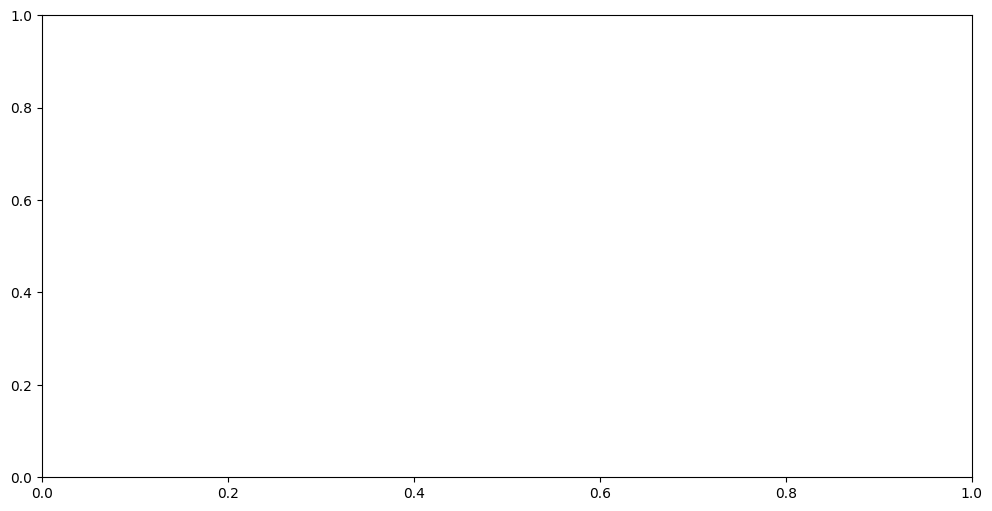

In [15]:
# 1.6 Graficar los datos almacenados

ARCHIVO  = "data.txt"
TÍTULO   ="Lectura de giroscopio - posición angular"
VARIABLE ="Theta [°]"
plot_data(ARCHIVO, TÍTULO, VARIABLE)

### **2. Suscribir mensajes en Pico W**

En este ejercicio publicaremos mensajes desde la laptop con el tópico `RXX/teleop/cmd` que serán suscritos en  la Pico W para controlar el movimiento del kit móvil.

In [3]:
# 2.1 Agregar librerías y definir tópico
import paho.mqtt.publish as publish

TOPIC_CMD = "R04/teleop/cmd"

In [5]:
# 2.2 Definir las funciones de conexión

def on_connect(client, userdata, flags, rc):
    """Se ejecuta al conectar con el broker"""
    if rc == 0:
        print(f"Conectado al broker: {BROKER} y tópico: {TOPIC_CMD}")
    else:
        print(f"Error de conexión. Código: {rc}")

def send_command(client, topic, msg):
    """ Publica un comando en formato string al tópico MQTT especificado"""
    payload = msg.encode("utf-8")
    client.publish(topic, payload)
    print(f"Comando publicado: {payload!r} → Tópico: '{topic}'", end='\r')

def send_command_dict(client, topic, msg):
    """ Publica un comando en formato string al tópico MQTT especificado"""
    payload = json.dumps(msg)
    client.publish(topic, payload)
    print(f"Comando publicado: {payload!r} → Tópico: '{topic}'", end='\r')

In [ ]:
# 2.3 Conectar a Broker MQTT y publicar cmd en tópico TOPIC_CMD

client = mqtt.Client()
client.on_connect = on_connect

try:
    client.connect(BROKER, PORT, keepalive=60)
    client.loop_start()
    
    print("\nTeleoperación iniciada")
    print("Comandos: w(adelante) s(atrás) a(izquierda) d(derecha) q(rotar) e(rotar) x(parar)")
    
    while True:
        cmd = input("Ingresa un comando:").strip()
        send_command(client, TOPIC_CMD, cmd)
            
except KeyboardInterrupt:
    print("\nTeleoperación finalizada")

except Exception as e:
    print(f"Error: {e}")
finally:
    client.loop_stop()
    client.disconnect()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7640\2288662619.py:3: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


In [6]:
# 2.4 Conectar a Broker MQTT y publicar diccionario en tópico TOPIC_CMD

import paho.mqtt.client as mqtt
client = mqtt.Client()
client.on_connect = on_connect

try:
    client.connect(BROKER, PORT, keepalive=60)
    client.loop_start()
    
    print("\nTeleoperación iniciada")
    print("Comandos: w(adelante) s(atrás) a(izquierda) d(derecha) q(rotar) e(rotar) x(parar)")
    
    while True:
        cmd = input("Ingresa un comando [w,s,a,d,q,e,x]: ").strip() [cite: 509]
        speed = input("Ingrese una velocidad [0 a 40]: ").strip() [cite: 509]

        command = {"cmd": cmd, "speed": speed} [cite: 510, 511]
        send_command_dict(client, TOPIC_CMD, command) [cite: 512]
            
except KeyboardInterrupt:
    print("\nTeleoperación finalizada")

except Exception as e:
    print(f"Error: {e}")
finally:
    client.loop_stop()
    client.disconnect()

Error: name 'BROKER' is not defined


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6024\4098469716.py:4: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()
